# Automated Visual Defect Detection with CNNs
### Manufacturing Quality Control — Casting Products (PyTorch)

**Business goal:** minimise **false negatives** (defective castings escaping to customers) while keeping **false positives** low enough that the line isn't flooded with manual re-checks.

**Positive class = `defective` (label 1).** Recall on this class is therefore the headline metric; precision tells us how many flagged parts are genuinely bad (i.e. the re-check burden).

| Section | Content |
|---|---|
| 0 | Setup & reproducibility |
| 1 | Data preparation & exploration |
| 2 | Phase 1 — Baseline CNN from scratch |
| 3 | Phase 2 — Improving on the baseline (two candidates + threshold tuning) |
| 4 | Head-to-head comparison on the same test set |
| 5 | Deployment considerations (latency, error analysis) |
| 6 | Key lessons & reflection |

## 0. Setup & reproducibility

In [1]:
import os, time, random, json, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve,
                             classification_report)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.models import resnet18, ResNet18_Weights

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__}")
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == 'cuda' else ''))
sns.set_theme(style='whitegrid')
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

PyTorch 2.11.0+cu128 | torchvision 0.26.0+cu128
Device: cuda (NVIDIA GeForce RTX 4050 Laptop GPU)


## 1. Data preparation & exploration

The Kaggle download contains two versions:
* `casting_512x512/` — 1,300 raw 512×512 images (no split).
* `casting_data/` — 7,348 **300×300 grayscale** images (augmented by the dataset author), with an **official train/test split**.

I use `casting_data/` because it is larger and its fixed test split means results are comparable to other work. Its `test/` folder is held out untouched until final evaluation; a stratified 15% of `train/` is carved off as a **validation set** for early stopping, model selection and threshold tuning.

In [2]:
# Works locally (archive/), on Kaggle (/kaggle/input/...) and on Colab (after unzipping into /content)
_candidates = [Path('archive/casting_data/casting_data'),
               Path('/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data'),
               Path('/content/casting_data/casting_data')]
DATA_ROOT = next((c for c in _candidates if c.exists()), _candidates[0])
print('DATA_ROOT =', DATA_ROOT)
CLASSES = {'ok_front': 0, 'def_front': 1}   # 1 = defective (positive class)
CLASS_NAMES = ['OK', 'Defective']

def list_split(split):
    paths, labels = [], []
    for folder, lab in CLASSES.items():
        files = sorted((DATA_ROOT / split / folder).glob('*.jpeg'))
        paths += files; labels += [lab] * len(files)
    return paths, np.array(labels)

train_paths, train_labels = list_split('train')
test_paths, test_labels = list_split('test')

counts = pd.DataFrame({
    'split': ['train', 'train', 'test', 'test'],
    'class': ['OK', 'Defective'] * 2,
    'images': [(train_labels == 0).sum(), (train_labels == 1).sum(), (test_labels == 0).sum(), (test_labels == 1).sum()],
})
counts['share'] = counts.groupby('split')['images'].transform(lambda s: s / s.sum()).round(3)
display(counts)

w, h = Image.open(train_paths[0]).size
print(f"Image size: {w}x{h}, mode: {Image.open(train_paths[0]).mode}")

DATA_ROOT = archive\casting_data\casting_data


,split,class,images,share
0,train,OK,2875,0.433
1,train,Defective,3758,0.567
2,test,OK,262,0.366
3,test,Defective,453,0.634


Image size: 300x300, mode: RGB


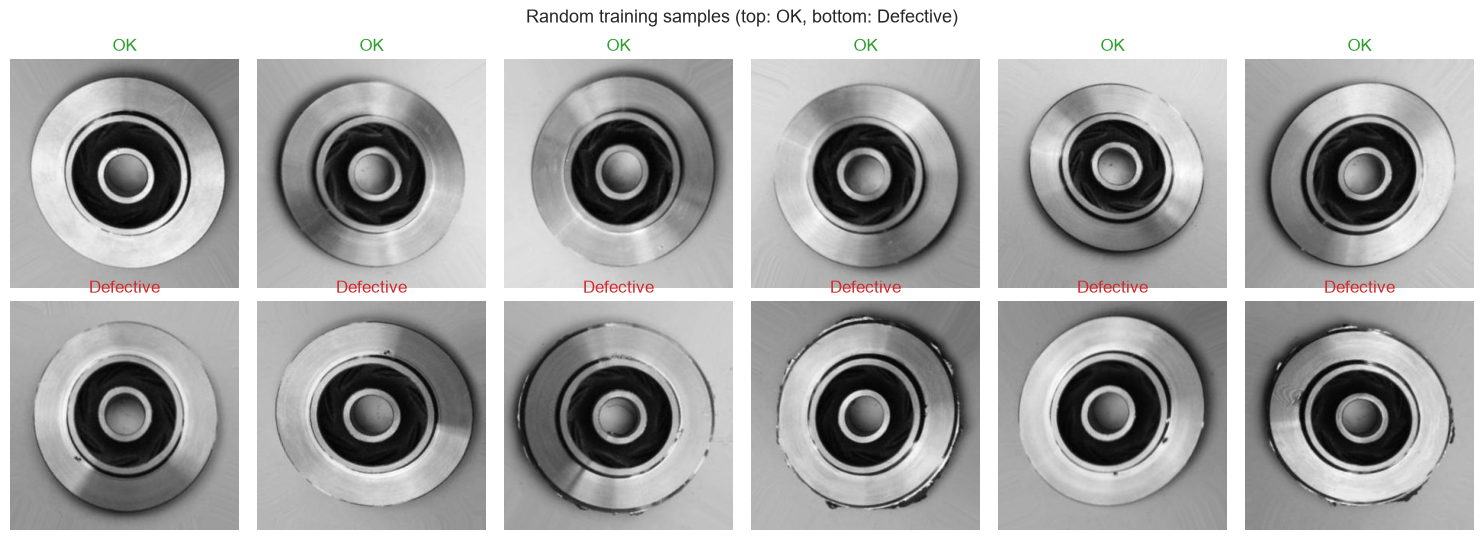

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
rng = np.random.default_rng(SEED)
for row, lab in enumerate([0, 1]):
    idx = rng.choice(np.where(train_labels == lab)[0], 6, replace=False)
    for ax, i in zip(axes[row], idx):
        ax.imshow(Image.open(train_paths[i]).convert('L'), cmap='gray'); ax.axis('off')
        ax.set_title(CLASS_NAMES[lab], color='tab:green' if lab == 0 else 'tab:red')
plt.suptitle('Random training samples (top: OK, bottom: Defective)', fontsize=13)
plt.tight_layout(); plt.savefig(FIG_DIR / 'samples.png', dpi=110); plt.show()

**Observations:** images are top-down shots of the impeller under consistent lighting, so colour carries no information — they are loaded as **single-channel grayscale**. Defects (blow holes, pinholes, burrs, shrinkage, edge chips) are often **small and local**, which argues against aggressive down-sampling. The class split is mildly imbalanced (~57% defective), so accuracy alone would be misleading and I report precision/recall/F1 too.

To make training fast I decode every image once into an in-memory `uint8` tensor (≈ 7.3k × 224 × 224 ≈ 370 MB) instead of re-reading JPEGs each epoch.

In [4]:
IMG_SIZE = 224

def load_tensor(paths, size=IMG_SIZE):
    arr = np.empty((len(paths), 1, size, size), dtype=np.uint8)
    for i, p in enumerate(paths):
        arr[i, 0] = np.asarray(Image.open(p).convert('L').resize((size, size), Image.BILINEAR))
    return torch.from_numpy(arr)

t0 = time.time()
X_all = load_tensor(train_paths); y_all = torch.from_numpy(train_labels).float()
X_test = load_tensor(test_paths); y_test = torch.from_numpy(test_labels).float()
print(f"Loaded in {time.time() - t0:.1f}s  | train+val {tuple(X_all.shape)}  test {tuple(X_test.shape)}")

tr_idx, va_idx = train_test_split(np.arange(len(y_all)), test_size=0.15, stratify=train_labels, random_state=SEED)
X_train, y_train = X_all[tr_idx], y_all[tr_idx]
X_val, y_val = X_all[va_idx], y_all[va_idx]
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f"{name:5s}: {len(yy):5d} images | defective share = {yy.mean():.3f}")

# Dataset-level normalisation statistics (computed on the training split only, to avoid leakage)
PIX_MEAN = X_train.float().div(255).mean().item(); PIX_STD = X_train.float().div(255).std().item()
print(f"Train pixel mean={PIX_MEAN:.3f}, std={PIX_STD:.3f}")

Loaded in 73.0s  | train+val (6633, 1, 224, 224)  test (715, 1, 224, 224)
train:  5638 images | defective share = 0.567
val  :   995 images | defective share = 0.567
test :   715 images | defective share = 0.634
Train pixel mean=0.564, std=0.237


### Shared training / evaluation utilities
Everything below is reused by every model so that the comparison is fair: same splits, same loss (`BCEWithLogitsLoss`), same early-stopping rule (best validation loss), same metrics.

Augmentation is done **on the GPU in batch** (cheap and fast). I chose transforms that reflect how the part can genuinely appear on the line: the impeller is **rotationally symmetric**, so any rotation / flip is label-preserving; small brightness/contrast jitter simulates lighting drift; a slight random zoom/shift simulates positioning tolerance on the conveyor.

In [6]:
def augment(x):
    # x: float tensor (B,1,H,W) in [0,1] on device
    B = x.size(0)
    # random 90-degree rotations + flips (label preserving: impeller is rotationally symmetric)
    k = random.randint(0, 3)
    x = torch.rot90(x, k, dims=(2, 3))
    flip = torch.rand(B, device=x.device) < 0.5
    x = torch.where(flip[:, None, None, None], x.flip(3), x)
    # small arbitrary rotation + scale + translation via affine grid
    ang = (torch.rand(B, device=x.device) - 0.5) * 2 * np.pi / 12          # +-15 deg
    scale = 1 + (torch.rand(B, device=x.device) - 0.5) * 0.2              # 0.9 - 1.1
    tx, ty = [(torch.rand(B, device=x.device) - 0.5) * 0.1 for _ in range(2)]
    cos, sin = torch.cos(ang) / scale, torch.sin(ang) / scale
    theta = torch.stack([torch.stack([cos, -sin, tx], 1), torch.stack([sin, cos, ty], 1)], 1)
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    x = F.grid_sample(x, grid, padding_mode='reflection', align_corners=False)
    # brightness / contrast jitter
    b = 1 + (torch.rand(B, 1, 1, 1, device=x.device) - 0.5) * 0.3
    c = 1 + (torch.rand(B, 1, 1, 1, device=x.device) - 0.5) * 0.3
    m = x.mean(dim=(2, 3), keepdim=True)
    return ((x - m) * c + m * b).clamp(0, 1)


def batches(X, y, bs, shuffle):
    idx = torch.randperm(len(X)) if shuffle else torch.arange(len(X))
    for i in range(0, len(X), bs):
        j = idx[i:i + bs]
        yield X[j], y[j]


def train(model, prep, epochs, lr, bs=64, aug=False, param_groups=None, weight_decay=0.0,
          patience=5, name='model'):
    # prep: fn(uint8 batch on device) -> model-ready float input
    model.to(device)
    opt = torch.optim.AdamW(param_groups or model.parameters(), lr=lr, weight_decay=weight_decay)
    steps = epochs * ((len(X_train) + bs - 1) // bs)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[g['lr'] for g in opt.param_groups],
                                                total_steps=steps, pct_start=0.2)
    crit = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler(enabled=device.type == 'cuda')
    hist = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'val_recall']}
    best, best_state, bad = float('inf'), None, 0
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train(); tl, tc, n = 0.0, 0, 0
        for xb, yb in batches(X_train, y_train, bs, True):
            xb, yb = xb.to(device, non_blocking=True).float().div(255), yb.to(device)
            if aug: xb = augment(xb)
            with torch.autocast(device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                logits = model(prep(xb)).squeeze(1)
                loss = crit(logits.float(), yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
            tl += loss.item() * len(yb); tc += ((logits > 0) == (yb > 0.5)).sum().item(); n += len(yb)
        vp = predict_proba(model, prep, X_val)
        vl = F.binary_cross_entropy(torch.tensor(vp).clamp(1e-7, 1 - 1e-7), y_val).item()
        hist['train_loss'].append(tl / n); hist['train_acc'].append(tc / n)
        hist['val_loss'].append(vl); hist['val_acc'].append(accuracy_score(y_val, vp > 0.5))
        hist['val_recall'].append(recall_score(y_val, vp > 0.5))
        flag = ''
        if vl < best:
            best, best_state, bad, flag = vl, copy.deepcopy(model.state_dict()), 0, '  *best*'
        else:
            bad += 1
        print(f"[{name}] ep {ep:2d}/{epochs} | train loss {tl/n:.4f} acc {tc/n:.4f} | "
              f"val loss {vl:.4f} acc {hist['val_acc'][-1]:.4f} recall {hist['val_recall'][-1]:.4f}{flag}")
        if bad >= patience:
            print(f"[{name}] early stopping (no val-loss improvement for {patience} epochs)"); break
    model.load_state_dict(best_state)
    print(f"[{name}] done in {time.time() - t0:.0f}s, best val loss {best:.4f}")
    return hist


@torch.no_grad()
def predict_proba(model, prep, X, bs=256):
    model.eval(); out = []
    for i in range(0, len(X), bs):
        xb = X[i:i + bs].to(device).float().div(255)
        with torch.autocast(device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            out.append(torch.sigmoid(model(prep(xb)).float().squeeze(1)).cpu())
    return torch.cat(out).numpy()


def metrics(y_true, prob, thr=0.5):
    pred = (prob >= thr).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    return {'threshold': thr, 'accuracy': accuracy_score(y_true, pred), 'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred), 'f1': f1_score(y_true, pred), 'roc_auc': roc_auc_score(y_true, prob),
            'TN': int(cm[0, 0]), 'FP': int(cm[0, 1]), 'FN': int(cm[1, 0]), 'TP': int(cm[1, 1])}


def plot_history(hist, title, fname):
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(hist['train_loss'], 'o-', label='train'); ax[0].plot(hist['val_loss'], 'o-', label='val'); ax[0].set_title('Loss')
    ax[1].plot(hist['train_acc'], 'o-', label='train'); ax[1].plot(hist['val_acc'], 'o-', label='val'); ax[1].set_title('Accuracy')
    ax[2].plot(hist['val_recall'], 'o-', color='tab:red', label='val recall (defective)'); ax[2].set_title('Validation recall @0.5')
    for a in ax: a.set_xlabel('epoch'); a.legend()
    fig.suptitle(title, fontsize=13); plt.tight_layout(); plt.savefig(FIG_DIR / fname, dpi=110); plt.show()


def plot_cm(m, title, ax):
    cm = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot_kws={'size': 14})
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)

count_params = lambda m: sum(p.numel() for p in m.parameters())
RESULTS = {}

## 2. Phase 1 — Baseline CNN from scratch

**Design (deliberately simple — this is the reference point):**
* Input: 128×128 grayscale (down-sampled from 300×300 to keep the from-scratch model cheap).
* 4 × [Conv3×3 → ReLU → MaxPool2×2] with 32→64→128→128 filters.
* Flatten → Dense(128) → Dropout(0.5) → Dense(1) (logit).
* No batch-norm, no augmentation, Adam-style optimiser (AdamW, no weight decay), lr 1e-3, up to 20 epochs with early stopping.

In [7]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(1, 32), block(32, 64), block(64, 128), block(128, 128))  # 128 -> 8
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(128 * 8 * 8, 128), nn.ReLU(inplace=True),
                                        nn.Dropout(0.5), nn.Linear(128, 1))
    def forward(self, x):
        return self.classifier(self.features(x))

prep_small = lambda x: (F.interpolate(x, size=128, mode='bilinear', antialias=True, align_corners=False) - PIX_MEAN) / PIX_STD

set_seed()
baseline = BaselineCNN()
print(baseline)
print(f"Trainable parameters: {count_params(baseline):,}")

BaselineCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (

[baseline] ep  1/20 | train loss 0.6042 acc 0.6566 | val loss 0.4369 acc 0.8000 recall 0.6897  *best*
[baseline] ep  2/20 | train loss 0.3668 acc 0.8430 | val loss 0.4662 acc 0.7608 recall 0.9557
[baseline] ep  3/20 | train loss 0.2781 acc 0.8852 | val loss 0.3088 acc 0.8583 recall 0.9787  *best*
[baseline] ep  4/20 | train loss 0.1843 acc 0.9275 | val loss 0.0959 acc 0.9739 recall 0.9663  *best*
[baseline] ep  5/20 | train loss 0.1215 acc 0.9526 | val loss 0.0907 acc 0.9658 recall 0.9397  *best*
[baseline] ep  6/20 | train loss 0.0890 acc 0.9700 | val loss 0.0622 acc 0.9739 recall 0.9539  *best*
[baseline] ep  7/20 | train loss 0.0577 acc 0.9808 | val loss 0.0730 acc 0.9719 recall 0.9982
[baseline] ep  8/20 | train loss 0.0431 acc 0.9860 | val loss 0.0348 acc 0.9869 recall 0.9770  *best*
[baseline] ep  9/20 | train loss 0.0424 acc 0.9846 | val loss 0.0178 acc 0.9960 recall 0.9929  *best*
[baseline] ep 10/20 | train loss 0.0284 acc 0.9906 | val loss 0.0123 acc 0.9980 recall 0.9965  *be

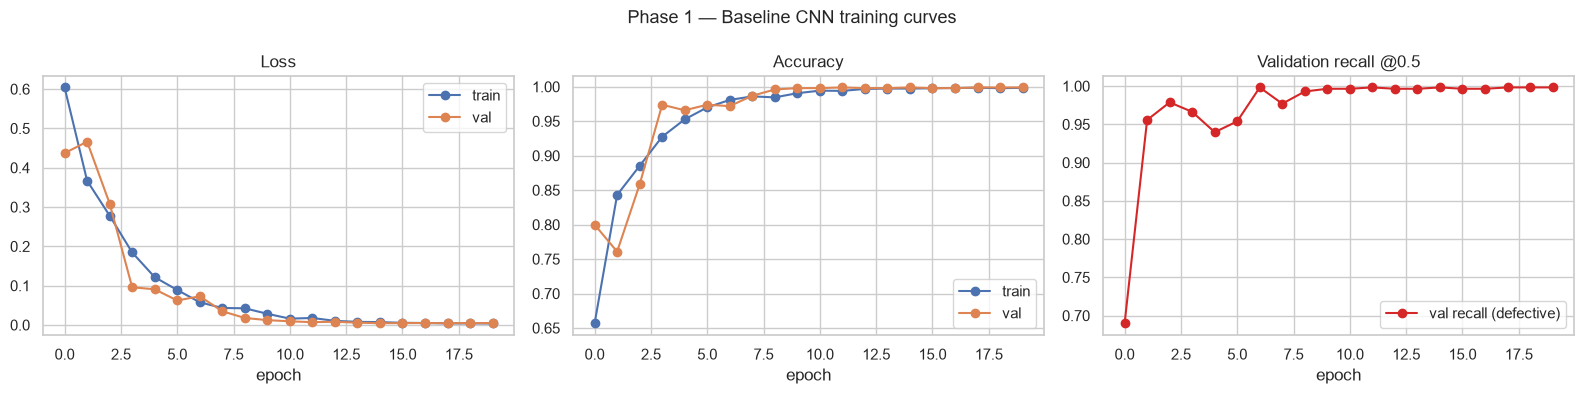

In [8]:
set_seed()
hist_base = train(baseline, prep_small, epochs=20, lr=1e-3, bs=64, aug=False, patience=5, name='baseline')
plot_history(hist_base, 'Phase 1 — Baseline CNN training curves', 'hist_baseline.png')

              precision    recall  f1-score   support

          OK     0.9850    1.0000    0.9924       262
   Defective     1.0000    0.9912    0.9956       453

    accuracy                         0.9944       715
   macro avg     0.9925    0.9956    0.9940       715
weighted avg     0.9945    0.9944    0.9944       715



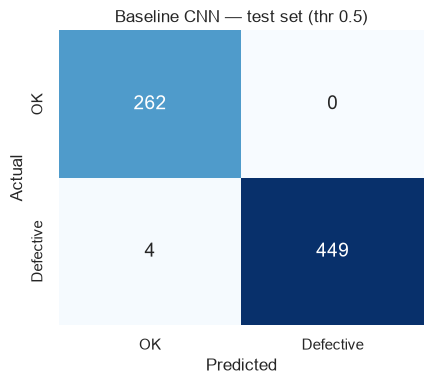

,threshold,accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP
Baseline CNN,0.5,0.9944,1.0,0.9912,0.9956,1.0,262.0,0.0,4.0,449.0


In [9]:
p_base_test = predict_proba(baseline, prep_small, X_test)
RESULTS['Baseline CNN'] = metrics(test_labels, p_base_test)
print(classification_report(test_labels, p_base_test >= 0.5, target_names=CLASS_NAMES, digits=4))
fig, ax = plt.subplots(figsize=(4.5, 4)); plot_cm(RESULTS['Baseline CNN'], 'Baseline CNN — test set (thr 0.5)', ax)
plt.tight_layout(); plt.savefig(FIG_DIR / 'cm_baseline.png', dpi=110); plt.show()
pd.DataFrame(RESULTS).T.round(4)

## 3. Phase 2 — Improving on the baseline

### 3.1 Diagnosing the baseline first
Before picking a technique I looked at *why* the baseline makes mistakes (see curves/matrix above):
1. **Over-fitting signal** — training loss keeps falling while validation loss flattens/rises: the model memorises rather than generalises. Remedies: augmentation, batch-norm, weight decay, fewer dense parameters.
2. **Resolution** — at 128×128 the small pinholes/blow-holes become just a few pixels. Remedy: larger input (224).
3. **Operating point** — a 0.5 threshold is arbitrary; the business cost of a FN is far higher than a FP. Remedy: choose the threshold on the validation set to hit a recall target.

### 3.2 Options considered
| Option | Pros | Cons | Decision |
|---|---|---|---|
| **A. Regularised scratch CNN** (BN, GAP head, augmentation, weight decay, 224 px) | Small & fast; no external weights; isolates the effect of regularisation/augmentation | Must learn all features from ~5.6k images | **Try** — a controlled ablation |
| **B. Transfer learning — ResNet18 (ImageNet), full fine-tune + augmentation** | Pre-trained edge/texture filters transfer well to surface defects; converges fast; still light enough for real-time CPU/edge inference | ImageNet ≠ grayscale metal; 11M params | **Try** — main candidate |
| Bigger backbones (ResNet50, EfficientNet-B3, ViT) | Potentially higher ceiling | 2–8× slower inference; little headroom left on this dataset; harder edge deployment | Rejected — cost > likely gain |
| Class re-weighting / oversampling | Handles imbalance | Imbalance here is mild (57/43) and *favours* the positive class; threshold tuning achieves the same cost trade-off more transparently | Rejected in favour of threshold tuning |
| Extensive hyper-parameter search | Squeezes extra points | Expensive; risks over-fitting the validation set | Light manual tuning only |
| Anomaly detection (train only on OK parts) | Useful when defects are rare/unlabelled | We *have* plenty of labelled defects; supervised is stronger here | Rejected |

Both A and B are trained with the **same** split, loss, early stopping and evaluation code as the baseline. The winner is chosen on **validation** performance, then its decision threshold is tuned on validation, and only then is it scored on the untouched test set.

### 3.3 Candidate A — Regularised CNN from scratch (+ augmentation, BN, GAP, 224 px)

Trainable parameters: 2,353,569  (baseline: 1,289,089)
[cand_A] ep  1/25 | train loss 0.3263 acc 0.8652 | val loss 0.2558 acc 0.8784 recall 0.7855  *best*
[cand_A] ep  2/25 | train loss 0.1649 acc 0.9450 | val loss 0.6919 acc 0.6593 recall 1.0000
[cand_A] ep  3/25 | train loss 0.0982 acc 0.9698 | val loss 0.1572 acc 0.9357 recall 0.9982  *best*
[cand_A] ep  4/25 | train loss 0.0646 acc 0.9810 | val loss 0.0538 acc 0.9809 recall 0.9663  *best*
[cand_A] ep  5/25 | train loss 0.0681 acc 0.9780 | val loss 0.1054 acc 0.9598 recall 0.9752
[cand_A] ep  6/25 | train loss 0.1145 acc 0.9647 | val loss 0.0850 acc 0.9749 recall 0.9965
[cand_A] ep  7/25 | train loss 0.0417 acc 0.9881 | val loss 0.0201 acc 0.9940 recall 0.9894  *best*
[cand_A] ep  8/25 | train loss 0.0307 acc 0.9920 | val loss 1.2512 acc 0.6804 recall 1.0000
[cand_A] ep  9/25 | train loss 0.0501 acc 0.9853 | val loss 0.0093 acc 0.9980 recall 0.9965  *best*
[cand_A] ep 10/25 | train loss 0.0266 acc 0.9927 | val loss 0.0389 acc 0.9970

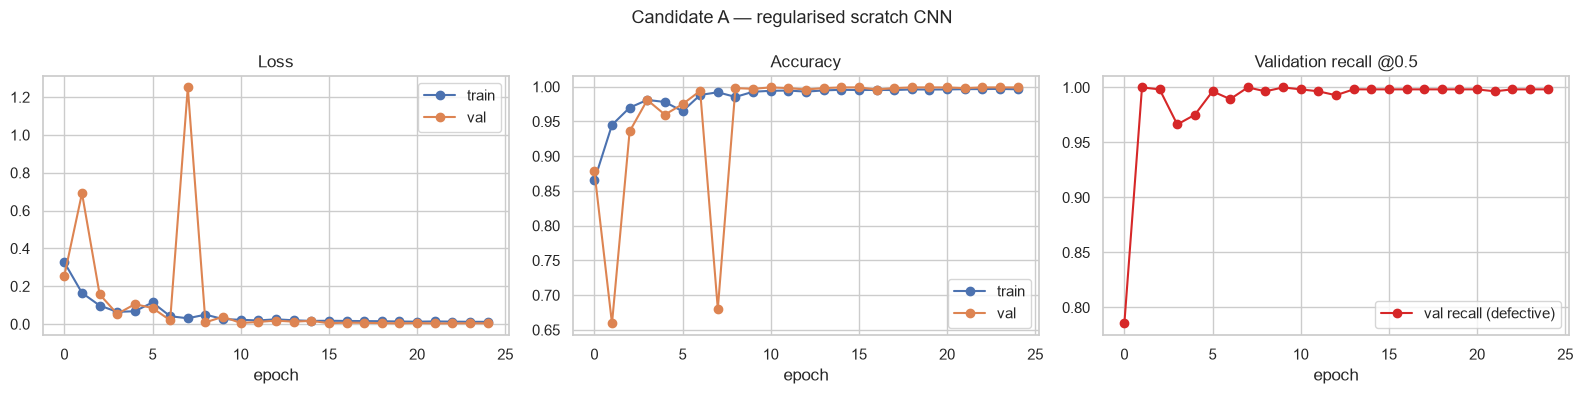

In [10]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                                 nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                                 nn.MaxPool2d(2))
        self.features = nn.Sequential(block(1, 32), block(32, 64), block(64, 128), block(128, 256), block(256, 256))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, 1))
    def forward(self, x):
        return self.head(self.features(x))

prep_224 = lambda x: (x - PIX_MEAN) / PIX_STD

set_seed()
cand_a = ImprovedCNN()
print(f"Trainable parameters: {count_params(cand_a):,}  (baseline: {count_params(baseline):,})")
hist_a = train(cand_a, prep_224, epochs=25, lr=2e-3, bs=64, aug=True, weight_decay=1e-4, patience=7, name='cand_A')
plot_history(hist_a, 'Candidate A — regularised scratch CNN', 'hist_candA.png')

### 3.4 Candidate B — Transfer learning with ResNet18 (ImageNet pre-trained)
* Grayscale is replicated to 3 channels and normalised with ImageNet statistics so the pre-trained filters see familiar input.
* The final FC layer is replaced by Dropout(0.3) → Linear(512, 1).
* **Discriminative learning rates:** backbone 3e-4 (gently adapt pre-trained features), new head 3e-3 (learn from scratch). One-cycle schedule, weight decay 1e-4, same augmentation as A.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ketro/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Trainable parameters: 11,177,025
[cand_B] ep  1/12 | train loss 0.2017 acc 0.9181 | val loss 0.0286 acc 0.9910 recall 0.9965  *best*
[cand_B] ep  2/12 | train loss 0.0306 acc 0.9911 | val loss 0.0529 acc 0.9819 recall 0.9947
[cand_B] ep  3/12 | train loss 0.0270 acc 0.9918 | val loss 0.0198 acc 0.9930 recall 0.9876  *best*
[cand_B] ep  4/12 | train loss 0.0168 acc 0.9949 | val loss 0.0264 acc 0.9910 recall 0.9840
[cand_B] ep  5/12 | train loss 0.0132 acc 0.9963 | val loss 0.0073 acc 0.9970 recall 0.9947  *best*
[cand_B] ep  6/12 | train loss 0.0121 acc 0.9959 | val loss 0.0067 acc 0.9970 recall 0.9947  *best*
[cand_B] ep  7/12 | train loss 0.0129 acc 0.9963 | val loss 0.0075 acc 0.9980 recall 0.9965
[cand_B] ep  8/12 | train loss 0.0207 acc 0.9947 | val loss 0.0077 acc 0.9970 recall 0.9947
[cand_B] ep  9/12 | train loss 0.0116 acc 0.9963 | val loss 0.0081 acc 0.9970 recall 0.9947
[cand_B] ep 10/12 | train loss 0.0105 acc 0.9965 | val loss 0.0070 acc 0.9970 recall 0.9947
[cand_B] ep 11/

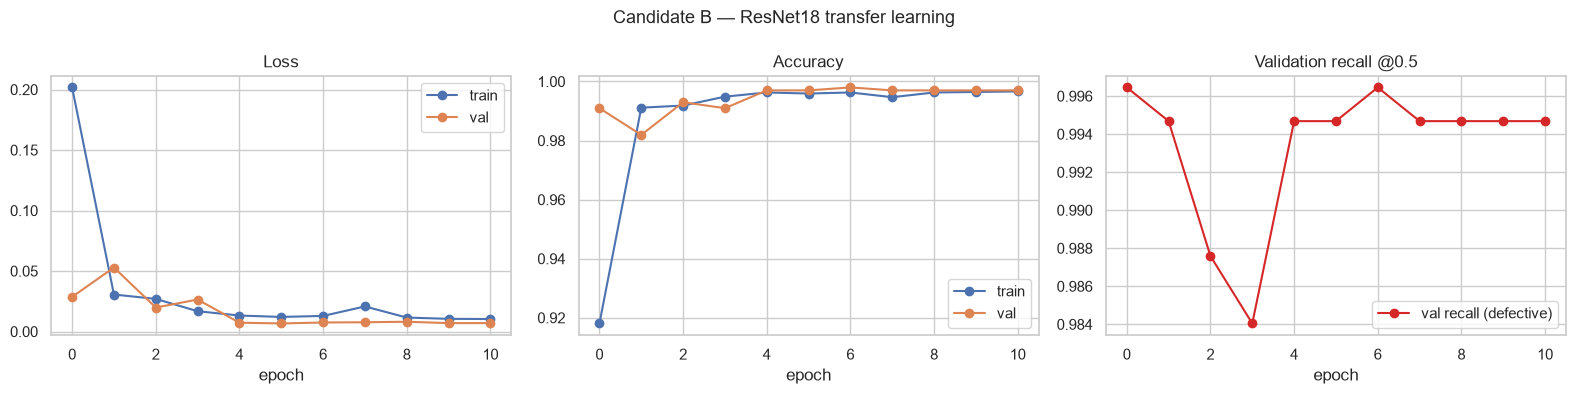

In [11]:
IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
IMNET_STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
prep_imnet = lambda x: (x.expand(-1, 3, -1, -1) - IMNET_MEAN) / IMNET_STD

def make_resnet18():
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, 1))
    return m

set_seed()
cand_b = make_resnet18()
groups = [{'params': [p for n, p in cand_b.named_parameters() if not n.startswith('fc.')], 'lr': 3e-4},
          {'params': cand_b.fc.parameters(), 'lr': 3e-3}]
print(f"Trainable parameters: {count_params(cand_b):,}")
hist_b = train(cand_b, prep_imnet, epochs=12, lr=3e-4, bs=64, aug=True, param_groups=groups,
               weight_decay=1e-4, patience=5, name='cand_B')
plot_history(hist_b, 'Candidate B — ResNet18 transfer learning', 'hist_candB.png')

### 3.5 Model selection on the validation set

In [12]:
models_ = {'Baseline CNN': (baseline, prep_small), 'Cand A: Regularised CNN': (cand_a, prep_224),
           'Cand B: ResNet18 TL': (cand_b, prep_imnet)}
val_probs = {k: predict_proba(m, p, X_val) for k, (m, p) in models_.items()}
val_table = pd.DataFrame({k: metrics(y_val.numpy(), v) for k, v in val_probs.items()}).T
display(val_table.round(4))

best_name = val_table.sort_values(['roc_auc', 'f1'], ascending=False).index[0]
print(f"Selected on validation: {best_name}")

,threshold,accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP
Baseline CNN,0.5,0.999,1.0,0.9982,0.9991,1.0,431.0,0.0,1.0,563.0
Cand A: Regularised CNN,0.5,0.998,1.0,0.9965,0.9982,1.0,431.0,0.0,2.0,562.0
Cand B: ResNet18 TL,0.5,0.997,1.0,0.9947,0.9973,1.0,431.0,0.0,3.0,561.0


Selected on validation: Cand A: Regularised CNN


### 3.6 Choosing the operating threshold for the business goal
A classifier outputs a probability; *where* we cut it is a business decision. Using the **validation set only**, I pick the threshold that:
1. achieves **recall ≥ 99.5 %** on defective parts (target: almost no escapes), and
2. among those thresholds, has the **highest precision** (fewest unnecessary re-checks).

The same procedure is applied to every model, so the comparison stays fair.

Baseline CNN               tuned threshold = 0.5803
Cand A: Regularised CNN    tuned threshold = 0.2035
Cand B: ResNet18 TL        tuned threshold = 0.3141


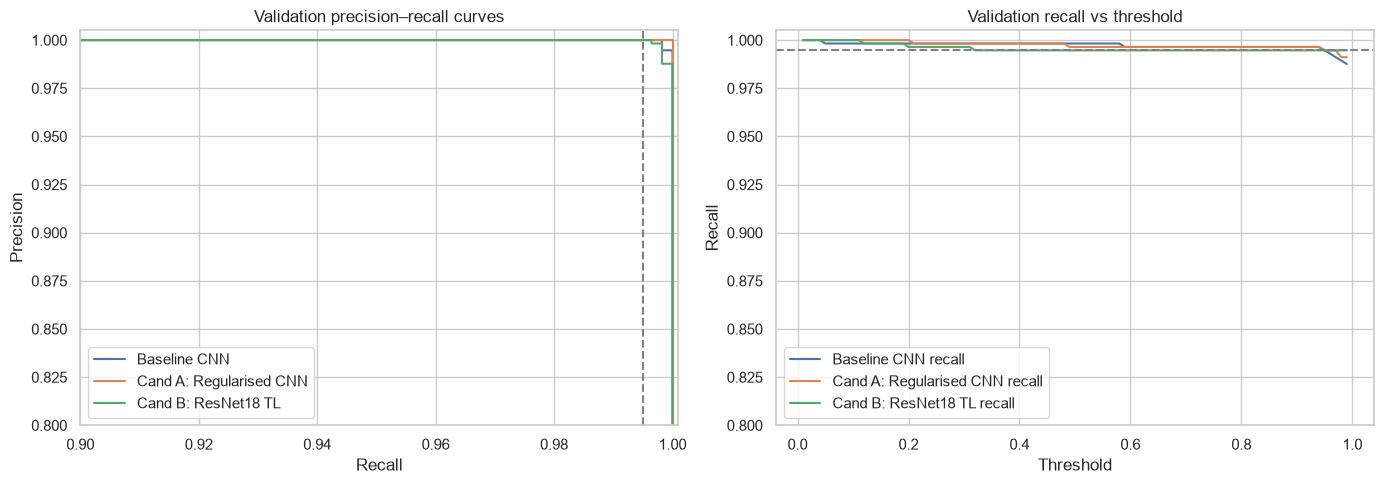

In [13]:
RECALL_TARGET = 0.995

def pick_threshold(y_true, prob, target=RECALL_TARGET):
    prec, rec, thr = precision_recall_curve(y_true, prob)
    prec, rec = prec[:-1], rec[:-1]            # align with thresholds
    ok = rec >= target
    i = np.argmax(np.where(ok, prec, -1))
    return float(thr[i])

thresholds = {k: pick_threshold(y_val.numpy(), v) for k, v in val_probs.items()}
for k, t in thresholds.items():
    print(f"{k:26s} tuned threshold = {t:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for k, v in val_probs.items():
    p, r, _ = precision_recall_curve(y_val.numpy(), v); ax[0].plot(r, p, label=k)
    thr_grid = np.linspace(0.01, 0.99, 99)
    ax[1].plot(thr_grid, [recall_score(y_val, v >= t) for t in thr_grid], label=f'{k} recall')
ax[0].axvline(RECALL_TARGET, ls='--', c='grey'); ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title('Validation precision–recall curves'); ax[0].set_xlim(0.9, 1.001); ax[0].set_ylim(0.8, 1.005); ax[0].legend()
ax[1].axhline(RECALL_TARGET, ls='--', c='grey'); ax[1].set_xlabel('Threshold'); ax[1].set_ylabel('Recall')
ax[1].set_title('Validation recall vs threshold'); ax[1].set_ylim(0.8, 1.005); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR / 'pr_threshold.png', dpi=110); plt.show()

## 4. Head-to-head comparison on the **same held-out test set** (715 images)
Each model is reported twice: at the default 0.5 threshold, and at its validation-tuned, recall-first threshold.

In [14]:
test_probs = {k: predict_proba(m, p, X_test) for k, (m, p) in models_.items()}
rows = {}
for k, v in test_probs.items():
    rows[(k, 'thr=0.50')] = metrics(test_labels, v, 0.5)
    rows[(k, 'tuned')] = metrics(test_labels, v, thresholds[k])
comparison = pd.DataFrame(rows).T
comparison.index.names = ['model', 'operating point']
display(comparison.style.format({c: '{:.4f}' for c in ['threshold', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']})
        .background_gradient(subset=['recall', 'f1'], cmap='Greens')
        .background_gradient(subset=['FN'], cmap='Reds'))

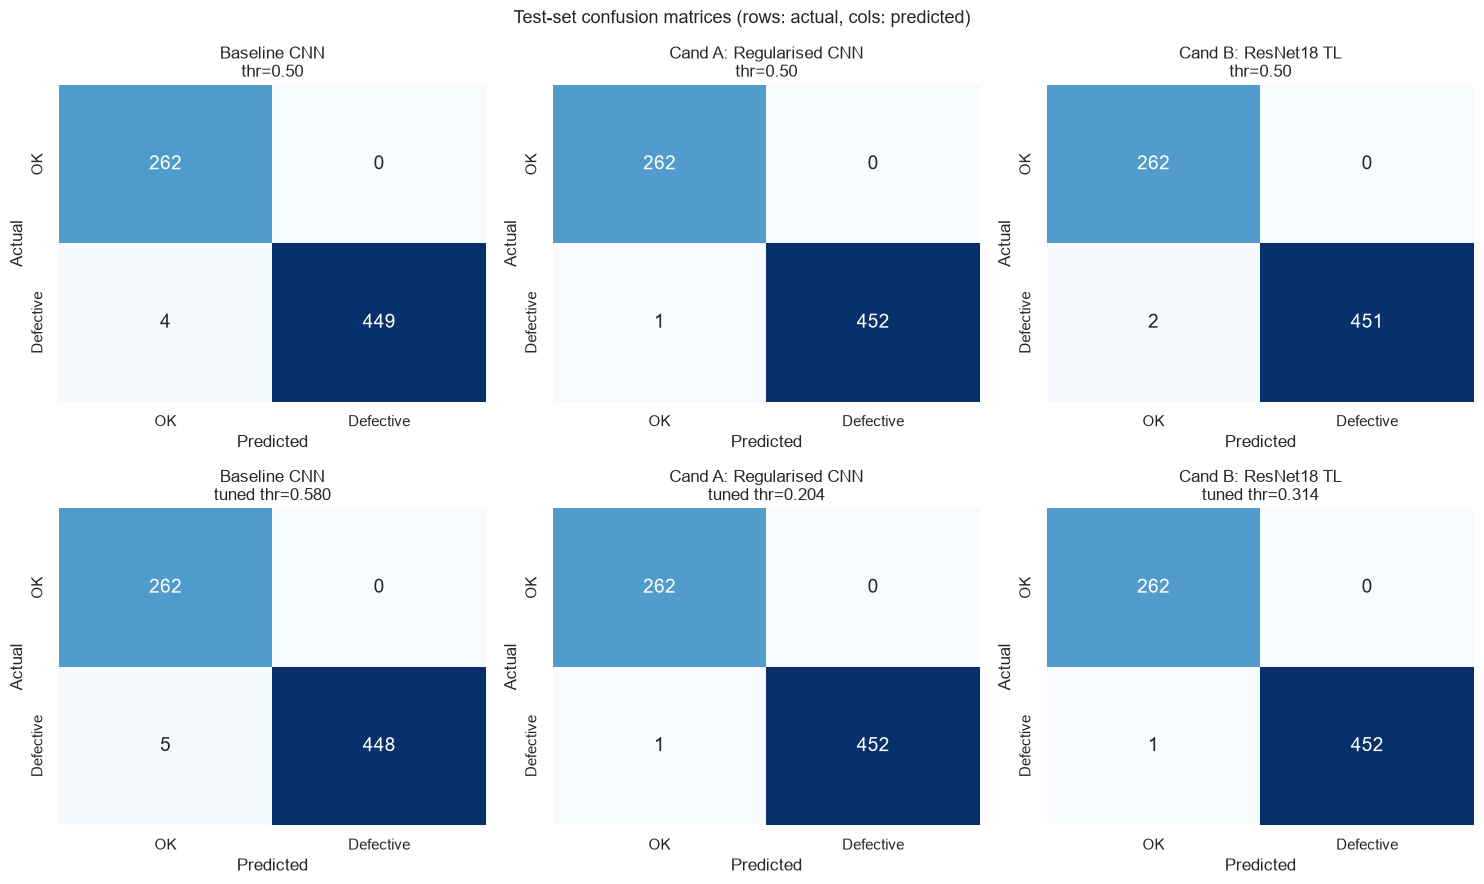

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for j, k in enumerate(models_):
    plot_cm(rows[(k, 'thr=0.50')], f"{k}\nthr=0.50", axes[0, j])
    plot_cm(rows[(k, 'tuned')], f"{k}\ntuned thr={thresholds[k]:.3f}", axes[1, j])
plt.suptitle('Test-set confusion matrices (rows: actual, cols: predicted)', fontsize=13)
plt.tight_layout(); plt.savefig(FIG_DIR / 'cm_all.png', dpi=110); plt.show()

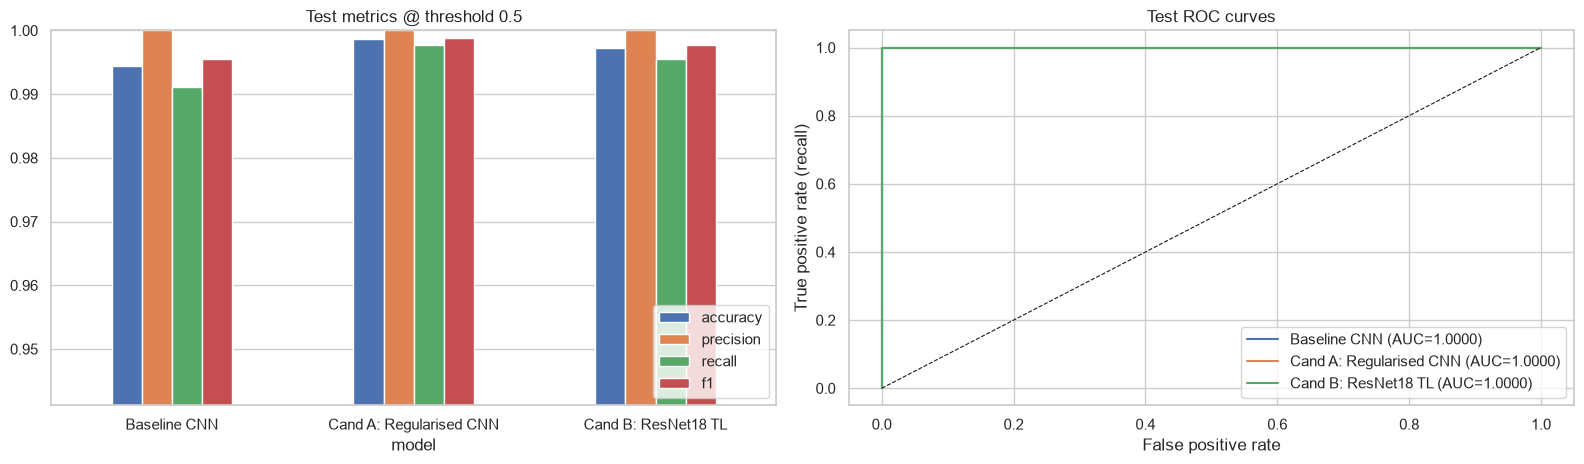

In [16]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1']
plot_df = comparison.xs('thr=0.50', level=1)[metric_cols]
fig, ax = plt.subplots(1, 2, figsize=(16, 4.8))
plot_df.plot.bar(ax=ax[0], rot=0, ylim=(max(0, plot_df.values.min() - 0.05), 1.0))
ax[0].set_title('Test metrics @ threshold 0.5'); ax[0].legend(loc='lower right')
for k, v in test_probs.items():
    fpr, tpr, _ = roc_curve(test_labels, v); ax[1].plot(fpr, tpr, label=f"{k} (AUC={roc_auc_score(test_labels, v):.4f})")
ax[1].plot([0, 1], [0, 1], 'k--', lw=0.8); ax[1].set_xlabel('False positive rate'); ax[1].set_ylabel('True positive rate (recall)')
ax[1].set_title('Test ROC curves'); ax[1].legend(loc='lower right')
plt.tight_layout(); plt.savefig(FIG_DIR / 'metrics_roc.png', dpi=110); plt.show()

## 5. Deployment considerations

### 5.1 Inference latency (real-time requirement)

In [17]:
def latency_ms(model, prep, dev, n=50):
    model = copy.deepcopy(model).to(dev).eval().float()
    x = X_test[:1].to(dev).float().div(255)
    with torch.no_grad():
        for _ in range(5): model(prep_on(prep, x, dev))
        if dev.type == 'cuda': torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n): model(prep_on(prep, x, dev))
        if dev.type == 'cuda': torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n * 1000

def prep_on(prep, x, dev):
    # prep closures reference GPU tensors for the ImageNet stats; rebuild on CPU when needed
    if prep is prep_imnet and dev.type == 'cpu':
        return (x.expand(-1, 3, -1, -1) - IMNET_MEAN.cpu()) / IMNET_STD.cpu()
    return prep(x)

lat = []
for k, (m, p) in models_.items():
    row = {'model': k, 'params (M)': count_params(m) / 1e6, 'CPU ms/image': latency_ms(m, p, torch.device('cpu'))}
    if device.type == 'cuda': row['GPU ms/image'] = latency_ms(m, p, device)
    lat.append(row)
lat_df = pd.DataFrame(lat).set_index('model').round(2); lat_df

,params (M),CPU ms/image,GPU ms/image
model,,,
Baseline CNN,1.29,3.52,2.33
Cand A: Regularised CNN,2.35,21.56,4.39
Cand B: ResNet18 TL,11.18,19.36,4.61


### 5.2 Error analysis — what does the selected model still get wrong?

Cand A: Regularised CNN @ tuned threshold 0.204: 1 false negatives, 0 false positives


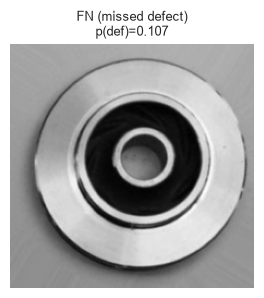

In [22]:
best_model, best_prep = models_[best_name]
p_best = test_probs[best_name]; t_best = thresholds[best_name]
pred = (p_best >= t_best).astype(int)
fn_idx = np.where((test_labels == 1) & (pred == 0))[0]
fp_idx = np.where((test_labels == 0) & (pred == 1))[0]
print(f"{best_name} @ tuned threshold {t_best:.3f}: {len(fn_idx)} false negatives, {len(fp_idx)} false positives")

show = [(i, 'FN (missed defect)') for i in fn_idx[:6]] + [(i, 'FP (false alarm)') for i in fp_idx[:6]]
if show:
    cols = min(6, len(show)); rows_ = int(np.ceil(len(show) / cols))
    fig, axes = plt.subplots(rows_, cols, figsize=(2.8 * cols, 3.1 * rows_), squeeze=False)
    for ax in axes.flat: ax.axis('off')
    for ax, (i, lab) in zip(axes.flat, show):
        ax.imshow(X_test[i, 0], cmap='gray'); ax.set_title(f"{lab}\np(def)={p_best[i]:.3f}", fontsize=9)
    plt.tight_layout(); plt.savefig(FIG_DIR / 'errors.png', dpi=110); plt.show()
else:
    print('No errors on the test set at this threshold.')

### 5.3 Grad-CAM — is the model looking at the defect?
A model can score well for the wrong reasons (e.g. background artefacts). Grad-CAM on the last conv block of the selected model shows which regions drove a "defective" decision — important for operator trust before deployment.

In [21]:
# Persist results + best model for the comparison report / deployment
torch.save(best_model.state_dict(), f"best_model_{'resnet18' if hasattr(best_model, 'layer4') else 'cnn'}.pt")
summary = {'selected_model': best_name, 'recall_target': RECALL_TARGET,
           'thresholds': thresholds,
           'test': {f"{k[0]} | {k[1]}": v for k, v in rows.items()},
           'validation@0.5': val_table.to_dict(orient='index'),
           'latency': lat_df.to_dict(orient='index'),
           'epochs_trained': {'Baseline CNN': len(hist_base['val_loss']), 'Cand A': len(hist_a['val_loss']), 'Cand B': len(hist_b['val_loss'])}}
with open('results.json', 'w') as f: json.dump(summary, f, indent=2, default=float)
print(json.dumps(summary['test'], indent=1, default=float)[:3000])

{
 "Baseline CNN | thr=0.50": {
  "threshold": 0.5,
  "accuracy": 0.9944055944055944,
  "precision": 1.0,
  "recall": 0.9911699779249448,
  "f1": 0.9955654101995566,
  "roc_auc": 1.0,
  "TN": 262,
  "FP": 0,
  "FN": 4,
  "TP": 449
 },
 "Baseline CNN | tuned": {
  "threshold": 0.5802925825119019,
  "accuracy": 0.993006993006993,
  "precision": 1.0,
  "recall": 0.9889624724061811,
  "f1": 0.9944506104328524,
  "roc_auc": 1.0,
  "TN": 262,
  "FP": 0,
  "FN": 5,
  "TP": 448
 },
 "Cand A: Regularised CNN | thr=0.50": {
  "threshold": 0.5,
  "accuracy": 0.9986013986013986,
  "precision": 1.0,
  "recall": 0.9977924944812362,
  "f1": 0.9988950276243094,
  "roc_auc": 0.9999831488128338,
  "TN": 262,
  "FP": 0,
  "FN": 1,
  "TP": 452
 },
 "Cand A: Regularised CNN | tuned": {
  "threshold": 0.20354916155338287,
  "accuracy": 0.9986013986013986,
  "precision": 1.0,
  "recall": 0.9977924944812362,
  "f1": 0.9988950276243094,
  "roc_auc": 0.9999831488128338,
  "TN": 262,
  "FP": 0,
  "FN": 1,
  "TP"